# NextTick - Phase 2: Classification Models

## Overview

This notebook trains and compares three models for **next-day direction prediction** - predicting whether a stock's close tomorrow will be higher (1) or lower (0) than today.

The three models represent three levels of sophistication:

1. **Logistic Regression** - linear baseline, no hyperparameter tuning
2. **Random Forest Classifier** - tree ensemble with cross-validated hyperparameter search
3. **LSTM Classifier** - deep sequence model with stacked LSTM layers, fixed architecture

Each model is trained on the same data split, evaluated with the same metrics, and saved to disk for later use by our Flask application.

## Data split

Chronological **70/15/15** train/validation/test. Chronological (not random) because this is time-series data - we train on the past and test on the future. The validation set is used for model selection / early stopping and the test set is only evaluated once at the end.

## Evaluation metrics

- **Accuracy** - fraction of correct predictions overall
- **Precision** - of predicted UP, fraction actually UP
- **Recall** - of actual UP, fraction correctly predicted UP
- **Macro F1** - balanced F1 averaging UP-class and DOWN-class F1 (appropriate for class-imbalanced data)
- **Confusion matrix** - full breakdown of predictions vs actuals

## Outputs

- `models/logistic_regression.pkl`
- `models/random_forest_classifier.pkl`
- `models/lstm_classifier.pt`
- `models/scaler.pkl` (the StandardScaler used to preprocess features)

## 1. Imports and Setup

We use PyTorch for the LSTM and scikit-learn for Logistic Regression and Random Forest. The LSTM needs a GPU kernel for speed - if `cuda` isn't available, training will still work but will be slower.

In [1]:
# Standard data stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
from pathlib import Path

# scikit-learn: classifiers, CV, scaling, metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

# PyTorch for the LSTM
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility - seed everything that could introduce randomness
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Device setup - use GPU if available, otherwise fall back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU:     {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
Device:  cuda
GPU:     NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load Dataset and Define Features

We load the 50-ticker dataset produced by Phase 1. The 21 features are already computed; we just need to specify which columns are features and which are targets.

In [2]:
# Load the dataset saved by Phase 1
df_full = pd.read_csv(
    "../data/processed/nexttick_dataset_50tickers.csv",
    index_col="Date",
    parse_dates=True,
).sort_index()

# The 21 features that will be fed to every model
FEATURE_COLS = [
    # Price / technical (6)
    "daily_return", "sma_10", "sma_20", "volatility_10", "momentum_10", "rsi_14",
    # Market / macro (10)
    "spy_return", "vix_level", "sector_return", "relative_to_spy", "relative_to_sector",
    "tnx_change", "dxy_change", "oil_return", "day_of_week", "month",
    # OHLCV-derived (5)
    "overnight_gap", "intraday_return", "daily_range_pct", "close_location", "relative_volume",
]
assert len(FEATURE_COLS) == 21

TARGET_COL = "target_direction"  # Binary target: 1 = UP, 0 = DOWN

print(f"Dataset: {df_full.shape}")
print(f"Tickers: {df_full['ticker'].nunique()}")
print(f"Date range: {df_full.index.min().date()} -> {df_full.index.max().date()}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Target:   {TARGET_COL}")

Dataset: (61750, 29)
Tickers: 50
Date range: 2021-05-18 -> 2026-04-17
Features: 21
Target:   target_direction


## 3. Chronological 70/15/15 Train/Val/Test Split

We split the data by date, not randomly. This is critical for time-series: we must train on earlier data and test on later data, because in production the model will always be predicting the future from the past.

- **Train** (70%): earliest dates - used to fit model parameters
- **Validation** (15%): middle dates - used for hyperparameter selection and early stopping
- **Test** (15%): latest dates - evaluated **once** at the end to report final performance

In [3]:
# Get all unique dates in sorted order, then pick cutoff dates at 70% and 85% positions
unique_dates = df_full.index.unique().sort_values()
n_dates = len(unique_dates)
train_cutoff = unique_dates[int(n_dates * 0.70)]
val_cutoff   = unique_dates[int(n_dates * 0.85)]

# Boolean masks for each split - all rows on all tickers for a given date go to the same split
train_mask = df_full.index <  train_cutoff
val_mask   = (df_full.index >= train_cutoff) & (df_full.index < val_cutoff)
test_mask  = df_full.index >= val_cutoff

# Extract feature matrices and target vectors for each split
X_train_raw = df_full.loc[train_mask, FEATURE_COLS].values
X_val_raw   = df_full.loc[val_mask,   FEATURE_COLS].values
X_test_raw  = df_full.loc[test_mask,  FEATURE_COLS].values

y_train = df_full.loc[train_mask, TARGET_COL].values.astype(int)
y_val   = df_full.loc[val_mask,   TARGET_COL].values.astype(int)
y_test  = df_full.loc[test_mask,  TARGET_COL].values.astype(int)

print(f"Split cutoffs: train<{train_cutoff.date()}  val<{val_cutoff.date()}  test>={val_cutoff.date()}")
print(f"Train: {train_mask.sum():>6,} rows  ({df_full.index[train_mask].min().date()} -> {df_full.index[train_mask].max().date()})")
print(f"Val:   {val_mask.sum():>6,} rows  ({df_full.index[val_mask].min().date()} -> {df_full.index[val_mask].max().date()})")
print(f"Test:  {test_mask.sum():>6,} rows  ({df_full.index[test_mask].min().date()} -> {df_full.index[test_mask].max().date()})")

# Show class balance in each split. These should be roughly similar across splits -
# if test has wildly different balance from train, it signals a regime shift.
print(f"\nClass balance (fraction UP):")
print(f"  Train: {y_train.mean():.3f}")
print(f"  Val:   {y_val.mean():.3f}")
print(f"  Test:  {y_test.mean():.3f}")

Split cutoffs: train<2024-10-23  val<2025-07-23  test>=2025-07-23
Train: 43,200 rows  (2021-05-18 -> 2024-10-22)
Val:    9,250 rows  (2024-10-23 -> 2025-07-22)
Test:   9,300 rows  (2025-07-23 -> 2026-04-17)

Class balance (fraction UP):
  Train: 0.520
  Val:   0.523
  Test:  0.511


## 4. Feature Scaling

Many features are on different scales - `daily_return` might be 0.01, `vix_level` might be 25, `sma_20` might be $200. Without scaling, linear models (LogReg) and neural networks (LSTM) train poorly. Random Forest doesn't need scaling, but we apply it uniformly so all three models consume the same preprocessed data.

**Important:** we fit the scaler **only on training data**, then apply it to validation and test. Fitting on the full dataset would leak information from the future into our training data.

In [4]:
# Fit the scaler on training data only - never fit on val or test
scaler = StandardScaler()
scaler.fit(X_train_raw)

# Apply the fitted scaler to all three splits
X_train = scaler.transform(X_train_raw).astype(np.float32)
X_val   = scaler.transform(X_val_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)

print(f"Scaled train shape: {X_train.shape}")
print(f"Scaled val shape:   {X_val.shape}")
print(f"Scaled test shape:  {X_test.shape}")
print(f"\nTrain mean (should be ~0):   max abs = {np.abs(X_train.mean(axis=0)).max():.4f}")
print(f"Train std (should be ~1):     min/max = {X_train.std(axis=0).min():.3f} / {X_train.std(axis=0).max():.3f}")

Scaled train shape: (43200, 21)
Scaled val shape:   (9250, 21)
Scaled test shape:  (9300, 21)

Train mean (should be ~0):   max abs = 0.0000
Train std (should be ~1):     min/max = 1.000 / 1.000


## 5. Model 1 - Logistic Regression

Our simplest classifier: a linear model that outputs `P(UP)` as a sigmoid-transformed weighted sum of features. No hyperparameter tuning - we train with default settings, which is appropriate for our goal of keeping a simple linear model as a reference point. We set a generous `max_iter` to ensure convergence on this dataset size.

In [5]:
print("Training Logistic Regression...")
start = time.time()

# Plain LogisticRegression with a high max_iter to guarantee convergence
logreg = LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1)
logreg.fit(X_train, y_train)

logreg_time = time.time() - start

# Evaluate on the test set
logreg_preds = logreg.predict(X_test)
logreg_acc  = accuracy_score(y_test, logreg_preds)
logreg_prec = precision_score(y_test, logreg_preds, zero_division=0)
logreg_rec  = recall_score(y_test, logreg_preds, zero_division=0)
logreg_f1   = f1_score(y_test, logreg_preds, average="macro")
logreg_cm   = confusion_matrix(y_test, logreg_preds)

print(f"Training complete in {logreg_time:.1f}s")
print(f"\nLogistic Regression - Test Performance\n")
print(f"Accuracy:  {logreg_acc:.4f}")
print(f"Precision: {logreg_prec:.4f}")
print(f"Recall:    {logreg_rec:.4f}")
print(f"Macro F1:  {logreg_f1:.4f}")
print(f"\nConfusion Matrix:")
print(pd.DataFrame(logreg_cm,
                    index=["actual DOWN", "actual UP"],
                    columns=["pred DOWN", "pred UP"]))
print(f"\nClassification Report:")
print(classification_report(y_test, logreg_preds, target_names=["DOWN", "UP"], zero_division=0))

Training Logistic Regression...
Training complete in 0.0s

Logistic Regression - Test Performance

Accuracy:  0.5068
Precision: 0.5097
Recall:    0.8917
Macro F1:  0.4107

Confusion Matrix:
             pred DOWN  pred UP
actual DOWN        479     4073
actual UP          514     4234

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.48      0.11      0.17      4552
          UP       0.51      0.89      0.65      4748

    accuracy                           0.51      9300
   macro avg       0.50      0.50      0.41      9300
weighted avg       0.50      0.51      0.42      9300



c:\Projects\NextTick\venv-gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## 6. Model 2 - Random Forest Classifier

Random Forest is an ensemble of decision trees. We tune three hyperparameters using **cross-validation** on the training set:

| Hyperparameter | Values | What it controls |
|---|---|---|
| `n_estimators` | 100, 200, 300, 400, 500 | Number of trees in the forest |
| `max_depth` | 5, 10, 20 | Maximum depth each tree is allowed to grow |
| `min_samples_leaf` | 5, 10 | Minimum samples required in each leaf node |

Total: 5 × 3 × 2 = **30 configurations**. We use `TimeSeriesSplit(5)` for cross-validation - this creates 5 expanding-window folds that respect time ordering (always train on past, validate on future), unlike standard k-fold which would shuffle randomly and leak future data.

The best config (by mean CV macro F1) is refit on the full training set and evaluated on test.

In [6]:
# The hyperparameter grid
rf_param_grid = {
    "n_estimators":      [100, 200, 300, 400, 500],
    "max_depth":         [5, 10, 20],
    "min_samples_leaf":  [5, 10],
}

total_configs = 1
for v in rf_param_grid.values():
    total_configs *= len(v)
print(f"RF grid: {total_configs} configs x 5 CV folds = {total_configs * 5} fits")

# Base estimator
rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)

# TimeSeriesSplit: 5 expanding-window folds that respect time order
tscv = TimeSeriesSplit(n_splits=5)

# GridSearchCV runs every config through every fold, scores with macro F1,
# picks the best-scoring config by mean CV score, and refits it on full train data
print("\nRunning RF grid search with TimeSeriesSplit(5) CV...")
start = time.time()

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

rf_time = time.time() - start
print(f"\nRF grid search complete in {rf_time/60:.1f} minutes")
print(f"Best CV macro F1: {rf_grid.best_score_:.4f}")
print(f"Best params: {rf_grid.best_params_}")

# Evaluate winning model on the test set
rf_best  = rf_grid.best_estimator_
rf_preds = rf_best.predict(X_test)

rf_acc  = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds, zero_division=0)
rf_rec  = recall_score(y_test, rf_preds, zero_division=0)
rf_f1   = f1_score(y_test, rf_preds, average="macro")
rf_cm   = confusion_matrix(y_test, rf_preds)

print(f"\nRandom Forest - Test Performance\n")
print(f"Accuracy:  {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall:    {rf_rec:.4f}")
print(f"Macro F1:  {rf_f1:.4f}")
print(f"\nConfusion Matrix:")
print(pd.DataFrame(rf_cm,
                    index=["actual DOWN", "actual UP"],
                    columns=["pred DOWN", "pred UP"]))
print(f"\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=["DOWN", "UP"], zero_division=0))

RF grid: 30 configs x 5 CV folds = 150 fits

Running RF grid search with TimeSeriesSplit(5) CV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

RF grid search complete in 3.0 minutes
Best CV macro F1: 0.4935
Best params: {'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 100}

Random Forest - Test Performance

Accuracy:  0.4991
Precision: 0.5075
Recall:    0.6380
Macro F1:  0.4873

Confusion Matrix:
             pred DOWN  pred UP
actual DOWN       1613     2939
actual UP         1719     3029

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.48      0.35      0.41      4552
          UP       0.51      0.64      0.57      4748

    accuracy                           0.50      9300
   macro avg       0.50      0.50      0.49      9300
weighted avg       0.50      0.50      0.49      9300



Top 10 features by RF importance:
       feature  importance
     vix_level      0.0841
    spy_return      0.0824
    oil_return      0.0822
    dxy_change      0.0790
    tnx_change      0.0752
 sector_return      0.0511
 overnight_gap      0.0448
close_location      0.0419
        rsi_14      0.0415
   momentum_10      0.0410


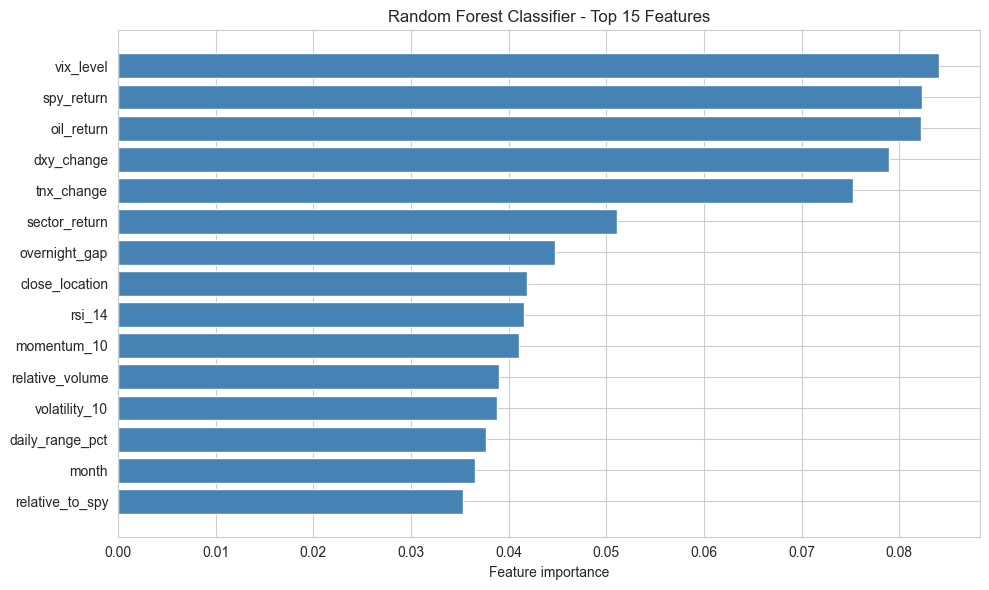

In [7]:
# Feature importance
rf_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_best.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 10 features by RF importance:")
print(rf_importance.head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Plot top 15 features horizontally
plt.figure(figsize=(10, 6))
top15 = rf_importance.head(15)
plt.barh(top15["feature"][::-1], top15["importance"][::-1], color="steelblue")
plt.xlabel("Feature importance")
plt.title("Random Forest Classifier - Top 15 Features")
plt.tight_layout()
plt.show()

## 7. Model 3 - LSTM Classifier

### Architecture

Stacked LSTM with a narrowing dimension pattern:

```
Input (batch, 30 timesteps, 21 features)
  -> LSTM layer 1: 64 hidden units, returns all timesteps
  -> Dropout 0.2
  -> LSTM layer 2: 32 hidden units, returns only final hidden state
  -> Dropout 0.2
  -> Dense(32 -> 16) + ReLU
  -> Dense(16 -> 1) + Sigmoid
```

The first LSTM reads the 30-day sequence and outputs a 64-dim vector per day. The second LSTM compresses this into a single 32-dim summary of the whole sequence. Two dense layers then produce a probability in [0, 1].

### Sequence construction

Each training sample is a **30-day window** of features ending at day t, paired with the direction label for day t. Windows are built **per ticker** - a window must not span two different stocks. This loses the first 29 rows of each ticker (they can't form a complete window).

### Training

- Loss: **Binary Cross-Entropy** (with logits for numerical stability; we apply sigmoid at inference)
- Optimizer: Adam, learning rate 1e-3
- Batch size: 64
- Max epochs: 30, early stopping patience: 5 on validation loss

In [8]:
# Hyperparameters for the LSTM
SEQ_LEN      = 30       # Length of input window in days
HIDDEN_1     = 64       # Hidden size of first LSTM layer
HIDDEN_2     = 32       # Hidden size of second LSTM layer
DENSE_HIDDEN = 16       # Hidden size of dense layer before output
DROPOUT      = 0.2      # Dropout rate between layers
BATCH_SIZE   = 64
LR           = 1e-3
MAX_EPOCHS   = 30
PATIENCE     = 5


def make_sequences_per_ticker(df_slice, X_scaled, y, seq_len=SEQ_LEN):
    """
    Build sliding-window sequences per ticker.
    """
    df_reset = df_slice.reset_index()
    X_windows, y_windows = [], []
    for ticker, group in df_reset.groupby("ticker"):
        # positions are the row indices of this ticker's rows within X_scaled
        positions = group.index.values
        if len(positions) < seq_len:
            continue  # not enough rows for even one window
        # Start at position seq_len-1 so the window goes from (i - seq_len + 1) through i inclusive
        for i in range(seq_len - 1, len(positions)):
            window_positions = positions[i - seq_len + 1 : i + 1]
            X_windows.append(X_scaled[window_positions])
            y_windows.append(y[positions[i]])
    return (
        np.array(X_windows, dtype=np.float32),
        np.array(y_windows, dtype=np.float32),
    )


class SequenceDataset(Dataset):
    """PyTorch Dataset wrapping numpy arrays of sequences and labels."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class LSTMClassifier(nn.Module):
    """
    Stacked LSTM classifier: two LSTM layers (64 -> 32) followed by two Dense layers (16 -> 1).
    Output is a raw logit; apply sigmoid at inference to get P(UP).
    """
    def __init__(self, n_features, hidden_1=HIDDEN_1, hidden_2=HIDDEN_2,
                 dense_hidden=DENSE_HIDDEN, dropout=DROPOUT):
        super().__init__()
        
        # LSTM 1: takes the raw 21-dim input, outputs a hidden_1-dim vector per timestep
        self.lstm1 = nn.LSTM(n_features, hidden_1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        
        # LSTM 2: takes LSTM 1's output (hidden_1 dim) and returns only the final hidden state
        self.lstm2 = nn.LSTM(hidden_1, hidden_2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        
        # Dense layers: hidden_2 -> dense_hidden -> 1
        self.dense1 = nn.Linear(hidden_2, dense_hidden)
        self.relu = nn.ReLU()
        self.output = nn.Linear(dense_hidden, 1)
    
    def forward(self, x):
        
        # LSTM 1 returns sequences - output shape (batch, seq_len, hidden_1)
        lstm1_out, _ = self.lstm1(x)
        lstm1_out = self.dropout1(lstm1_out)
        
        # LSTM 2 - take only the final hidden state.
        _, (h_n, _) = self.lstm2(lstm1_out)
        final_hidden = h_n[-1]
        final_hidden = self.dropout2(final_hidden)
        
        # Dense layers + final logit
        h = self.relu(self.dense1(final_hidden))
        logit = self.output(h).squeeze(-1)   # (batch,)
        return logit


# Build sliding-window sequences for each split
print(f"Building {SEQ_LEN}-day sliding windows per ticker...")
X_train_seq, y_train_seq = make_sequences_per_ticker(df_full[train_mask], X_train, y_train)
X_val_seq,   y_val_seq   = make_sequences_per_ticker(df_full[val_mask],   X_val,   y_val)
X_test_seq,  y_test_seq  = make_sequences_per_ticker(df_full[test_mask],  X_test,  y_test)

print(f"  Train windows: {X_train_seq.shape}")
print(f"  Val windows:   {X_val_seq.shape}")
print(f"  Test windows:  {X_test_seq.shape}")

# Wrap in PyTorch DataLoaders for batched iteration
train_loader = DataLoader(SequenceDataset(X_train_seq, y_train_seq), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SequenceDataset(X_val_seq,   y_val_seq),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SequenceDataset(X_test_seq,  y_test_seq),  batch_size=BATCH_SIZE, shuffle=False)

# Instantiate the model and move to GPU
lstm_clf = LSTMClassifier(n_features=len(FEATURE_COLS)).to(DEVICE)

# Quickcheck on parameter count
total_params = sum(p.numel() for p in lstm_clf.parameters())
print(f"\nModel parameters: {total_params:,}")
print(lstm_clf)

Building 30-day sliding windows per ticker...
  Train windows: (41750, 30, 21)
  Val windows:   (7800, 30, 21)
  Test windows:  (7850, 30, 21)

Model parameters: 35,361
LSTMClassifier(
  (lstm1): LSTM(21, 64, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (dense1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [9]:
# Loss and optimizer.
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(lstm_clf.parameters(), lr=LR)

# Early stopping state
best_val_loss = float("inf")
best_epoch = -1
best_state = None
patience_counter = 0
history = {"train_loss": [], "val_loss": []}

print(f"Training LSTM Classifier - up to {MAX_EPOCHS} epochs, patience {PATIENCE}")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | Status")
print("-" * 60)

start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    # Training pass
    lstm_clf.train()
    train_loss_sum = 0.0
    train_n = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        
        logits = lstm_clf(X_batch)
        loss = criterion(logits, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_sum += loss.item() * X_batch.size(0)
        train_n += X_batch.size(0)
    train_loss = train_loss_sum / train_n
    
    # Validation pass (no gradients)
    lstm_clf.eval()
    val_loss_sum = 0.0
    val_n = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = lstm_clf(X_batch)
            loss = criterion(logits, y_batch)
            val_loss_sum += loss.item() * X_batch.size(0)
            val_n += X_batch.size(0)
    val_loss = val_loss_sum / val_n
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    
    # Early stopping check
    # If val loss improved, save this as the new best and reset patience
    # Otherwise, increment patience counter; stop if we hit the limit
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in lstm_clf.state_dict().items()}
        patience_counter = 0
        status = "v best"
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{PATIENCE}"
    
    print(f"{epoch:>5} | {train_loss:>10.5f} | {val_loss:>10.5f} | {status}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val loss {best_val_loss:.5f} at epoch {best_epoch}.")
        break

lstm_time = time.time() - start
print(f"\nTraining complete in {lstm_time:.1f}s")

# Restore weights from the best epoch
lstm_clf.load_state_dict(best_state)
print(f"Restored weights from epoch {best_epoch}.")

Training LSTM Classifier - up to 30 epochs, patience 5
Epoch | Train Loss |   Val Loss | Status
------------------------------------------------------------
    1 |    0.68990 |    0.69841 | v best
    2 |    0.67978 |    0.71785 | patience 1/5
    3 |    0.65761 |    0.75553 | patience 2/5
    4 |    0.63428 |    0.79894 | patience 3/5
    5 |    0.61880 |    0.82882 | patience 4/5
    6 |    0.60490 |    0.83661 | patience 5/5

Early stopping at epoch 6. Best val loss 0.69841 at epoch 1.

Training complete in 14.6s
Restored weights from epoch 1.


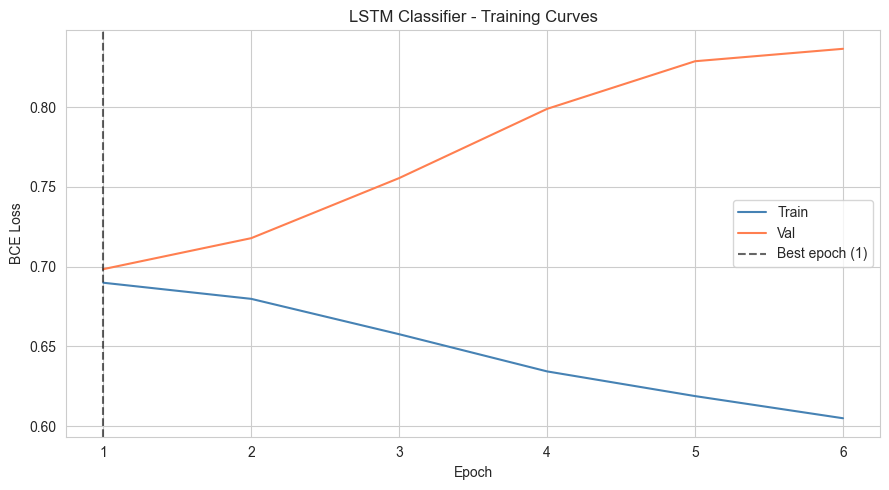

In [10]:
# Plot training curves to diagnose overfitting / early stopping behaviour
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train", color="steelblue")
plt.plot(epochs_ran, history["val_loss"],   label="Val",   color="coral")
plt.axvline(best_epoch, color="black", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("LSTM Classifier - Training Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Evaluate the LSTM on the test set
lstm_clf.eval()
all_logits = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = lstm_clf(X_batch)
        all_logits.append(logits.cpu().numpy())
        all_targets.append(y_batch.numpy())

# Concatenate batches and convert logits to probabilities, then to hard predictions
all_logits = np.concatenate(all_logits)
all_targets = np.concatenate(all_targets).astype(int)
probs = 1.0 / (1.0 + np.exp(-all_logits))   # sigmoid
lstm_preds = (probs >= 0.5).astype(int)

# Metrics
lstm_acc  = accuracy_score(all_targets, lstm_preds)
lstm_prec = precision_score(all_targets, lstm_preds, zero_division=0)
lstm_rec  = recall_score(all_targets, lstm_preds, zero_division=0)
lstm_f1   = f1_score(all_targets, lstm_preds, average="macro")
lstm_cm   = confusion_matrix(all_targets, lstm_preds)

print(f"LSTM Classifier - Test Performance\n")
print(f"Accuracy:  {lstm_acc:.4f}")
print(f"Precision: {lstm_prec:.4f}")
print(f"Recall:    {lstm_rec:.4f}")
print(f"Macro F1:  {lstm_f1:.4f}")
print(f"\nConfusion Matrix:")
print(pd.DataFrame(lstm_cm,
                    index=["actual DOWN", "actual UP"],
                    columns=["pred DOWN", "pred UP"]))
print(f"\nClassification Report:")
print(classification_report(all_targets, lstm_preds, target_names=["DOWN", "UP"], zero_division=0))

LSTM Classifier - Test Performance

Accuracy:  0.5139
Precision: 0.5171
Recall:    0.6970
Macro F1:  0.4944

Confusion Matrix:
             pred DOWN  pred UP
actual DOWN       1246     2604
actual UP         1212     2788

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.51      0.32      0.40      3850
          UP       0.52      0.70      0.59      4000

    accuracy                           0.51      7850
   macro avg       0.51      0.51      0.49      7850
weighted avg       0.51      0.51      0.50      7850



## 8. Model Comparison

All three classifiers evaluated on the same test set. The comparison table shows test-set metrics side by side, and we visualize the three confusion matrices together.

In [12]:
# Build the side-by-side comparison table
comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": logreg_acc, "Precision": logreg_prec,
     "Recall": logreg_rec, "Macro F1": logreg_f1},
    {"Model": "Random Forest",       "Accuracy": rf_acc,     "Precision": rf_prec,
     "Recall": rf_rec,     "Macro F1": rf_f1},
    {"Model": "LSTM",                "Accuracy": lstm_acc,   "Precision": lstm_prec,
     "Recall": lstm_rec,   "Macro F1": lstm_f1},
])

print("CLASSIFICATION MODEL COMPARISON - Test Set\n")
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Identify best model by macro F1
best_idx = comparison["Macro F1"].idxmax()
print(f"\nBest model by Macro F1: {comparison.loc[best_idx, 'Model']} ({comparison.loc[best_idx, 'Macro F1']:.4f})")

CLASSIFICATION MODEL COMPARISON - Test Set

              Model  Accuracy  Precision  Recall  Macro F1
Logistic Regression    0.5068     0.5097  0.8917    0.4107
      Random Forest    0.4991     0.5075  0.6380    0.4873
               LSTM    0.5139     0.5171  0.6970    0.4944

Best model by Macro F1: LSTM (0.4944)


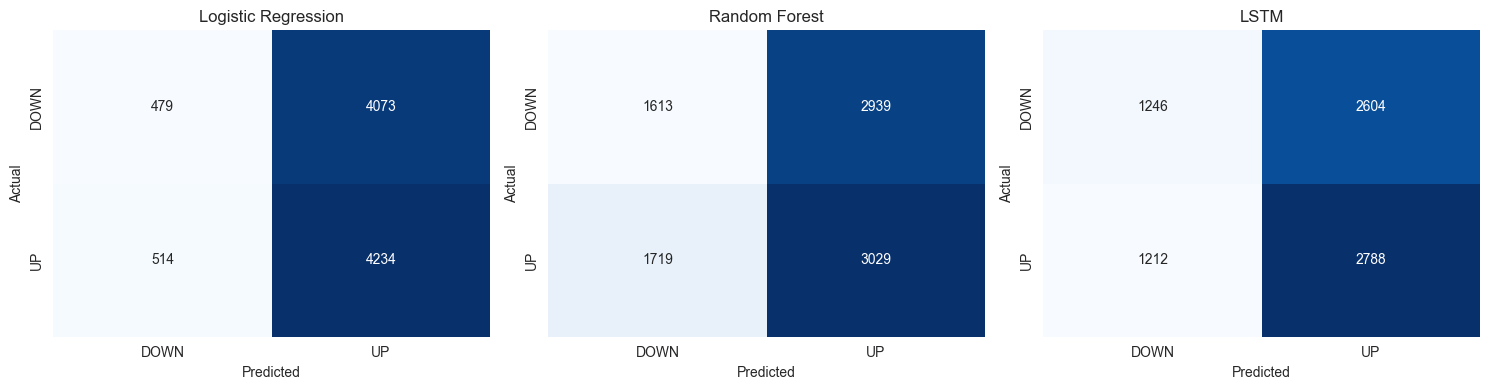

In [13]:
# Visualize all three confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cms = [("Logistic Regression", logreg_cm), ("Random Forest", rf_cm), ("LSTM", lstm_cm)]

for ax, (name, cm) in zip(axes, cms):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["DOWN", "UP"], yticklabels=["DOWN", "UP"],
                cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

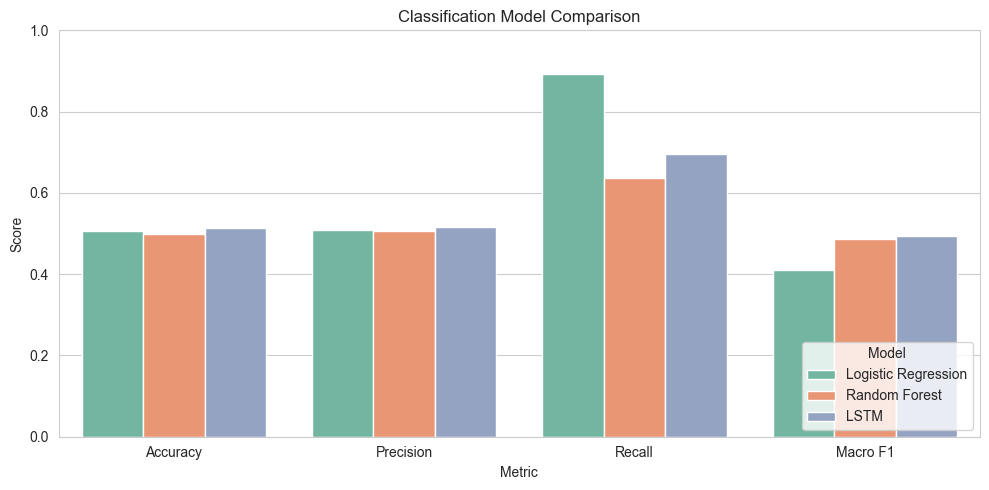

In [14]:
# Bar chart of metrics across models
metrics_long = comparison.melt(id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_long, x="Metric", y="Value", hue="Model", palette="Set2")
plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

## 9. Save Models

Save all three trained classifiers plus the fitted `StandardScaler` to the `models/` directory. These files will be consumed by our Flask app for inference.

- Logistic Regression and Random Forest: pickled via `pickle`
- LSTM: saved as full model via `torch.save` (includes architecture + weights)
- Scaler: pickled so preprocessing matches at inference time

In [15]:
# Create the models directory if it doesn't exist
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save Logistic Regression
with open(models_dir / "logistic_regression.pkl", "wb") as f:
    pickle.dump(logreg, f)

# Save Random Forest (the best estimator from the grid search)
with open(models_dir / "random_forest_classifier.pkl", "wb") as f:
    pickle.dump(rf_best, f)

# Save LSTM as a whole model - simpler for Flask to load than a state-dict approach
torch.save(lstm_clf, models_dir / "lstm_classifier.pt")

# Save the scaler - critical to preprocess new data identically at inference time
with open(models_dir / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# List what was saved
print("Saved models:")
for f in sorted(models_dir.glob("*regression*")) + sorted(models_dir.glob("*classifier*")) + sorted(models_dir.glob("scaler*")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<35} ({size_kb:>8.1f} KB)")

Saved models:
  logistic_regression.pkl             (     0.9 KB)
  lstm_classifier.pt                  (   144.1 KB)
  random_forest_classifier.pkl        ( 23419.4 KB)
  scaler.pkl                          (     0.9 KB)
